# Chapter 5 - Fractionally Differentiated Features

## Preparation

In [10]:
import os
import sys
sys.path.append(os.path.abspath(os.path.join('..')))

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.tsa.stattools import adfuller

from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import roc_curve, classification_report, confusion_matrix, accuracy_score
from sklearn.utils import resample, shuffle
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV

from utils.sampling_bars import dollar_bar
from utils.multiprocess import mpPandasObj

%matplotlib inline
plt.style.use('ggplot')
plt.rcParams['figure.figsize'] = 16,6

data_path = '../data/processed/clean_IVE_tickbidask.parq'
df = pd.read_parquet(data_path)

dollar_bars = dollar_bar(df)

## 1. Generate a time series from an IID Gaussian random process. This is a memory-less, stationary series:

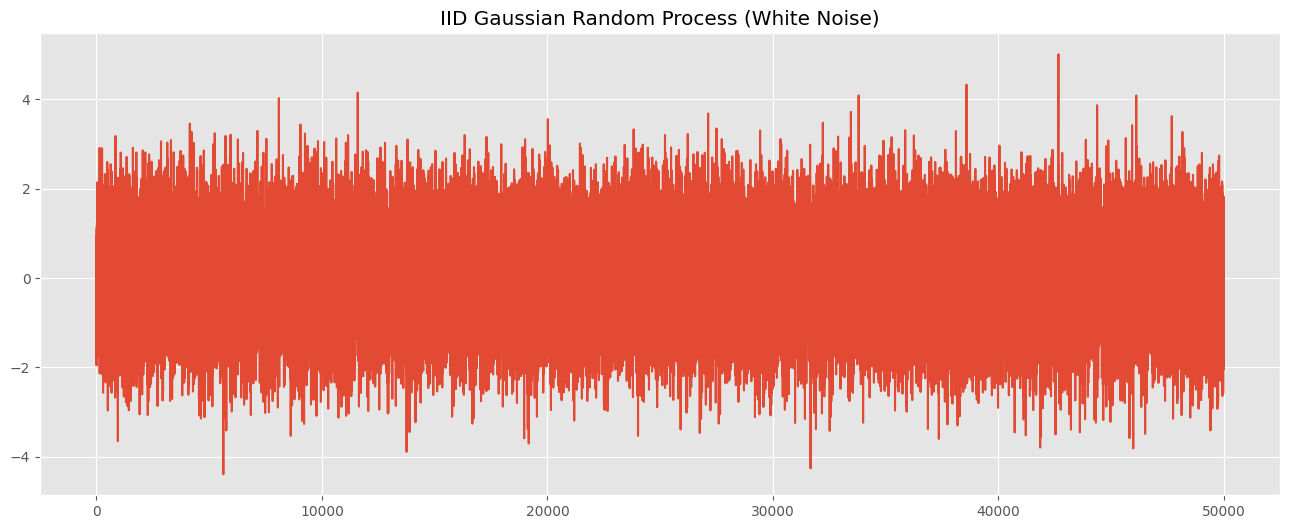

In [11]:
n_samples = 50000  # Number of points in the process
mu = 0            # Mean
sigma = 1         # Standard deviation

rng = np.random.default_rng(seed=42)
iid_process = rng.normal(loc=mu, scale=sigma, size=n_samples)

# Visualize the process
plt.plot(iid_process)
plt.title("IID Gaussian Random Process (White Noise)")
plt.show()

### a. Compute the ADF statistic on this series. What is the p-value?

In [12]:
result = adfuller(iid_process)

print(f'ADF Statistic: {result[0]}')
print(f'p-value: {result[1]}')
print(f'Critical Values: {result[4]}')

ADF Statistic: -223.19028852196203
p-value: 0.0
Critical Values: {'1%': np.float64(-3.4304807953310763), '5%': np.float64(-2.8615978088501315), '10%': np.float64(-2.566800769739017)}


### b. Compute the cumulative sum of the observations. This is a nonstationary  series without memory.

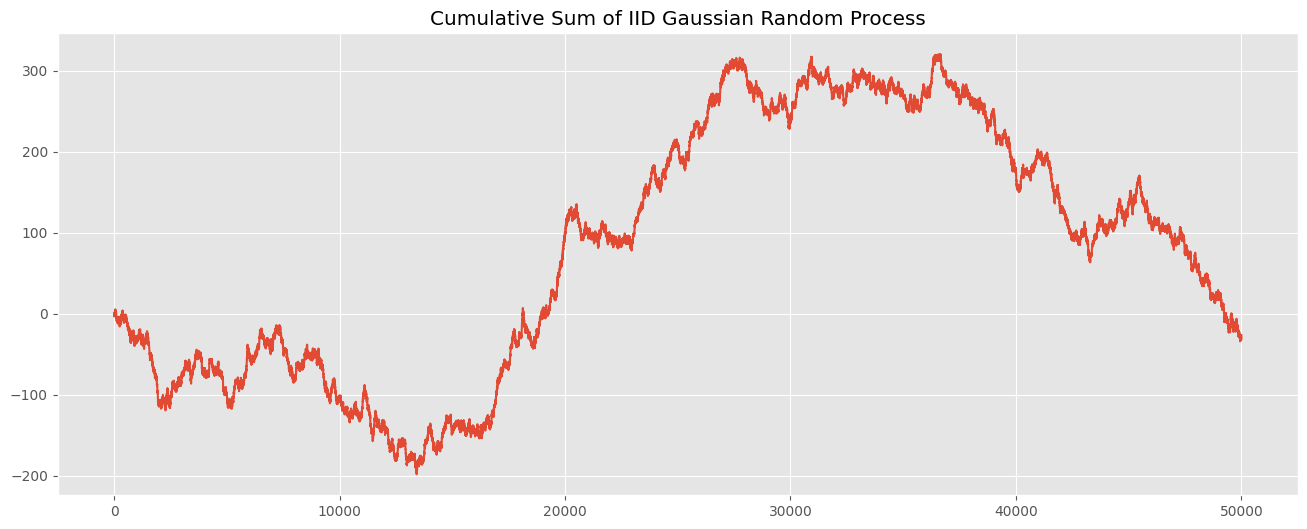

In [15]:
cum_sum = iid_process.cumsum()

plt.plot(cum_sum)
plt.title("Cumulative Sum of IID Gaussian Random Process")
plt.show()

#### i. What is the order of integration of this cumulative series?

This is order of integration of 1, since it takes 1 differentiation to make the time series to become stationary.

#### ii. Compute the ADF statistic on this series. What is the p-value?

In [17]:
result_cum_sum = adfuller(cum_sum)

print(f'ADF Statistic: {result_cum_sum[0]}')
print(f'p-value: {result_cum_sum[1]}')
print(f'Critical Values: {result_cum_sum[4]}')

ADF Statistic: -0.6562822533526006
p-value: 0.8577508677942011
Critical Values: {'1%': np.float64(-3.4304807953310763), '5%': np.float64(-2.8615978088501315), '10%': np.float64(-2.566800769739017)}


### c. Differentiate the series twice. What is the p-value of this overdifferentiated series?

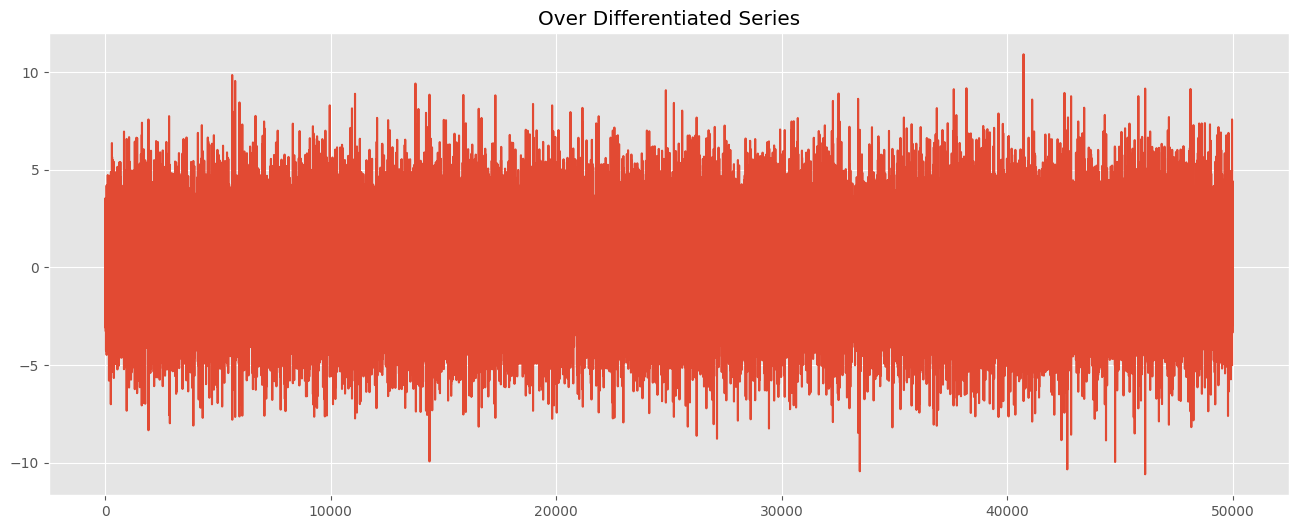

ADF Statistic: -65.44522359364991
p-value: 0.0
Critical Values: {'1%': np.float64(-3.430480949862939), '5%': np.float64(-2.8615978771485344), '10%': np.float64(-2.5668008060922607)}


In [19]:
over_diff_process = np.diff(np.diff(iid_process))

plt.plot(over_diff_process)
plt.title("Over Differentiated Series")
plt.show()

result_over_diff = adfuller(over_diff_process)

print(f'ADF Statistic: {result_over_diff[0]}')
print(f'p-value: {result_over_diff[1]}')
print(f'Critical Values: {result_over_diff[4]}')

Although the overly differentiated time series is also stationary, the variance is inflated, and we create a MA(1) series, compared to the original I(0) IID time series.

## Setup

Let $\{\varepsilon_t\}_{t=1}^{n} \overset{\text{iid}}{\sim} \mathcal{N}(0, \sigma^2)$. Applying `np.diff` to this already-stationary series **over-differences** it, producing:

$$ D_t = \varepsilon_t - \varepsilon_{t-1}, \quad t = 2, 3, \ldots, n $$

## Mean

By linearity of expectation:

$$ \mathbb{E}[D_t] = \mathbb{E}[\varepsilon_t] - \mathbb{E}[\varepsilon_{t-1}] = 0 - 0 = 0 $$

The mean remains **0**.[1]

## Variance

Since $\varepsilon_t$ and $\varepsilon_{t-1}$ are **independent** (IID assumption), the variance of their difference is:

$$ \text{Var}(D_t) = \text{Var}(\varepsilon_t) + \text{Var}(\varepsilon_{t-1}) = \sigma^2 + \sigma^2 = 2\sigma^2 $$

The variance **doubles** relative to the original process.[1]

## Key Consequence: Induced Autocorrelation

Over-differencing does not just inflate variance — it introduces a **negative MA(1) structure**. The lag-1 autocovariance is:

$$ \text{Cov}(D_t, D_{t-1}) = \text{Cov}(\varepsilon_t - \varepsilon_{t-1},\ \varepsilon_{t-1} - \varepsilon_{t-2}) = -\sigma^2 $$

This gives a lag-1 autocorrelation of:

$$ \rho_1 = \frac{-\sigma^2}{2\sigma^2} = -\frac{1}{2} $$

All higher lags $\rho_k = 0$ for $|k| \geq 2$. So `np.diff` of an IID process yields an **MA(1) process with coefficient $$\theta = -1$$** — a telltale sign of over-differencing in practice [2].

## Summary

| Property | Original $\varepsilon_t$ | Over-differenced $D_t$ |
|---|---|---|
| Mean | 0 | 0 |
| Variance | $\sigma^2$ | $2\sigma^2$ |
| Autocorrelation $\rho_1$ | 0 | $-1/2$ |
| Process type | I(0) white noise | MA(1), $\theta = -1$ |

## 2. Generate a time series that follows a sinusoidal function. This is a stationary  series with memory.

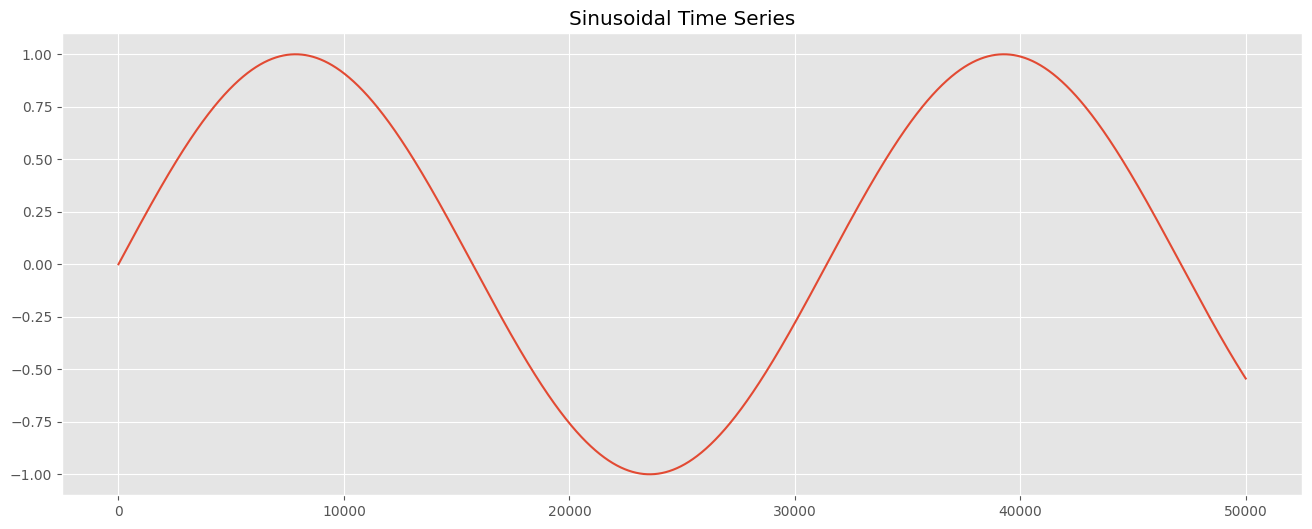

In [21]:
n_samples = 50000

sin_func = np.sin(np.linspace(0, 10, n_samples))

plt.plot(sin_func)
plt.title("Sinusoidal Time Series")
plt.show()

### a. Compute the ADF statistic on this series. What is the p-value?

In [22]:
result_sin_func = adfuller(sin_func)

print(f'ADF Statistic: {result_sin_func[0]}')
print(f'p-value: {result_sin_func[1]}')
print(f'Critical Values: {result_sin_func[4]}')

ADF Statistic: -208192930543.0748
p-value: 0.0
Critical Values: {'1%': np.float64(-3.4304808424377145), '5%': np.float64(-2.861597829669839), '10%': np.float64(-2.566800780820739)}


### b. Shift every observation by the same positive value. Compute the  cumulative sum of the observations. This is a nonstationary series with memory.